# AirBnB Prices - ML Reboot

Predicción del precio de alojamientos AirBnB a partir de sus características.

Recorrido:
1. Data Cleaning
2. Train-Test Split
3. Pipelines
4. Linear Regression
5. Cross-Validation
6. Fine-Tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

## 1. Data Loading

In [2]:
df = pd.read_csv('data/airbnb.csv', index_col=0)
print(df.shape)
df.head()

(2856, 21)


,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,30,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,1,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,1,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,1,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,2,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2856 entries, 0 to 2855
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   neighbourhood_cleansed  2856 non-null   int64  
 1   latitude                2856 non-null   float64
 2   longitude               2856 non-null   float64
 3   property_type           2856 non-null   object 
 4   room_type               2856 non-null   object 
 5   accommodates            2856 non-null   int64  
 6   bathrooms_text          2855 non-null   object 
 7   bedrooms                2693 non-null   float64
 8   beds                    2825 non-null   float64
 9   price                   2856 non-null   object 
 10  minimum_nights          2856 non-null   int64  
 11  number_of_reviews       2856 non-null   int64  
 12  review_scores_rating    2672 non-null   float64
 13  availability_365        2856 non-null   int64  
 14  instant_bookable        2856 non-null   objec

## 2. Data Cleaning

El dataset trae columnas que no aportan señal (identificadores, URLs, texto libre), la columna `price` viene como string con símbolos de dólar, `bathrooms_text` mezcla número y texto, y `instant_bookable` usa `t`/`f`. Vamos a saneralas.

In [4]:
drop_cols = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'description']
df = df.drop(columns=drop_cols)
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,30,90,4.50,285,f
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,1,359,4.58,179,t
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,1,67,4.52,0,t
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,1,306,4.71,199,t
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,2,51,4.98,78,f


In [5]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
df['price'].describe()

count     2856.000000
mean       195.723739
std        491.389346
min         19.000000
25%         98.000000
50%        140.000000
75%        225.000000
max      24999.000000
Name: price, dtype: float64

In [6]:
def parse_bathrooms(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s.startswith('half'):
        return 0.5
    token = s.split()[0]
    try:
        return float(token)
    except ValueError:
        return np.nan

df['bathrooms'] = df['bathrooms_text'].apply(parse_bathrooms)
df = df.drop(columns=['bathrooms_text'])
df['bathrooms'].describe()

count    2855.000000
mean        1.523993
std         0.835677
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: bathrooms, dtype: float64

In [7]:
df['instant_bookable'] = (df['instant_bookable'] == 't').astype(int)
df['instant_bookable'].value_counts()

instant_bookable
1    1653
0    1203
Name: count, dtype: int64

In [8]:
df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].astype(str)
df.dtypes

neighbourhood_cleansed     object
latitude                  float64
longitude                 float64
property_type              object
room_type                  object
accommodates                int64
bedrooms                  float64
beds                      float64
price                     float64
minimum_nights              int64
number_of_reviews           int64
review_scores_rating      float64
availability_365            int64
instant_bookable            int64
bathrooms                 float64
dtype: object

Filtramos precios extremos (outliers) para que el modelo lineal no se distorsione.

Filtrado: 2856 -> 2766 filas


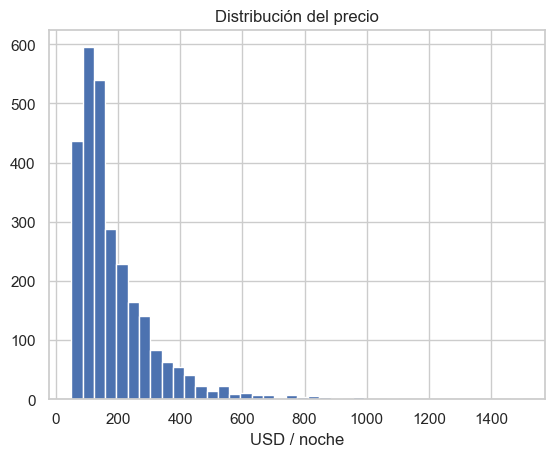

In [9]:
before = len(df)
df = df[(df['price'] >= 50) & (df['price'] <= 1500)].reset_index(drop=True)
print(f'Filtrado: {before} -> {len(df)} filas')
df['price'].hist(bins=40)
plt.title('Distribución del precio')
plt.xlabel('USD / noche')
plt.show()

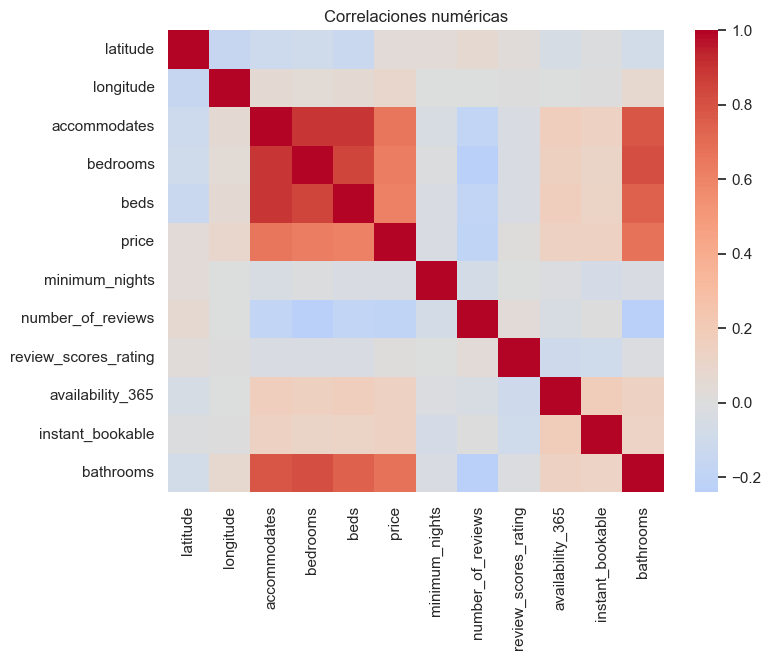

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlaciones numéricas')
plt.show()

## 3. Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(2212, 14) (554, 14)


## 4. Pipelines

Construimos un `ColumnTransformer` con dos ramas:

- **Numérica**: imputación de la mediana + `RobustScaler` (menos sensible a los outliers que quedan).
- **Categórica**: imputación por moda + `OneHotEncoder` con `min_frequency` para agrupar categorías raras.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print('Numéricas:', num_cols)
print('Categóricas:', cat_cols)

Numéricas: ['latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'instant_bookable', 'bathrooms']
Categóricas: ['neighbourhood_cleansed', 'property_type', 'room_type']


In [13]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', min_frequency=10)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bedrooms', 'beds', 'minimum_nights',
                                  'number_of_reviews', 'review_scores_rating',
                                  'availability_365', 'instant_bookable',
                                  'bathrooms']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=10))]),
                                 ['neighbourhood_cleansed', 'property_type',
                                  'room_type'])])

## 5. Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])

model.fit(X_train, y_train)
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f'R2 train: {train_r2:.3f}')
print(f'R2 test : {test_r2:.3f}')

R2 train: 0.645
R2 test : 0.494


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'MAE : {mae:.2f} USD')
print(f'RMSE: {rmse:.2f} USD')

MAE : 61.25 USD
RMSE: 102.29 USD


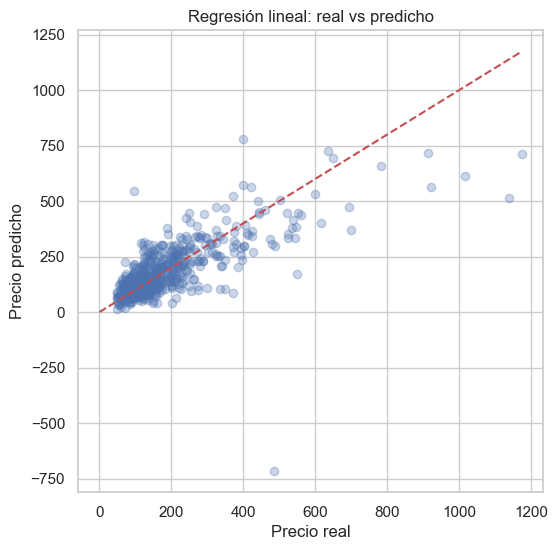

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3)
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Precio real')
ax.set_ylabel('Precio predicho')
ax.set_title('Regresión lineal: real vs predicho')
plt.show()

## 6. Cross-Validation

5-fold CV sobre el pipeline entero, así el preprocesamiento se refitea en cada fold y no hay fuga de información.

In [17]:
from sklearn.model_selection import cross_val_score, cross_validate

cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print('R2 por fold :', np.round(cv_r2, 3))
print(f'R2 medio   : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

cv = cross_validate(
    model, X_train, y_train, cv=5,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
)
print(f"MAE  medio : {-cv['test_neg_mean_absolute_error'].mean():.2f}")
print(f"RMSE medio : {-cv['test_neg_root_mean_squared_error'].mean():.2f}")

R2 por fold : [0.649 0.624 0.506 0.59  0.652]
R2 medio   : 0.604 ± 0.054
MAE  medio : 57.45
RMSE medio : 87.05


## 7. Fine-Tuning

`LinearRegression` no tiene hiperparámetros útiles, así que cambiamos a `ElasticNet` (regularización L1+L2) y tuneamos `alpha` y `l1_ratio` con `GridSearchCV`.

In [18]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=10000, random_state=42)),
])

param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.5, 0.9],
}

grid = GridSearchCV(
    tuned, param_grid, cv=5, scoring='r2', n_jobs=-1,
)
grid.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid.best_params_)
print(f'R2 CV mejor: {grid.best_score_:.3f}')

Mejores hiperparámetros: {'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.9}
R2 CV mejor: 0.605


In [19]:
best = grid.best_estimator_
print(f'R2 train : {best.score(X_train, y_train):.3f}')
print(f'R2 test  : {best.score(X_test, y_test):.3f}')

y_pred_best = best.predict(X_test)
print(f'MAE  test: {mean_absolute_error(y_test, y_pred_best):.2f}')
print(f'RMSE test: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}')

R2 train : 0.644
R2 test  : 0.493
MAE  test: 61.34
RMSE test: 102.43


In [20]:
results = pd.DataFrame(grid.cv_results_)
results = results[['param_regressor__alpha', 'param_regressor__l1_ratio', 'mean_test_score', 'std_test_score']]
results = results.sort_values('mean_test_score', ascending=False)
results.head(10)

,param_regressor__alpha,param_regressor__l1_ratio,mean_test_score,std_test_score
2,0.01,0.9,0.604680,0.048571
1,0.01,0.5,0.600627,0.043859
0,0.01,0.1,0.596862,0.042829
5,0.10,0.9,0.594359,0.041826
4,0.10,0.5,0.579435,0.039231
3,0.10,0.1,0.570699,0.037279
8,1.00,0.9,0.559027,0.034284
7,1.00,0.5,0.506216,0.030022
6,1.00,0.1,0.469176,0.029595
11,10.00,0.9,0.405085,0.027605


## Conclusiones

- Partimos de un dataset con columnas sucias (precio con `$`, baños como texto, booleanos `t`/`f`) y lo dejamos listo para entrenar.
- El `ColumnTransformer` separa limpiamente numéricas y categóricas, de modo que cualquier cambio de modelo reaprovecha el mismo preprocesamiento.
- `LinearRegression` da una baseline decente; `ElasticNet` con `GridSearchCV` controla el sobreajuste al regularizar los coeficientes one-hot de categorías raras.
- Próximos pasos razonables: log-transformar el precio, añadir features derivadas (precio por huésped, distancia al centro) y probar modelos no lineales (RandomForest, GradientBoosting).